## Connecting Python with SQL & NoSQL Database

In [2]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["sales_db"]
collection = db["sales"]

In [3]:
data = [
    {"product": "Laptop", "price": 1000, "quantity": 2, "date": "2026-04-15", "city": "Cairo"},
    {"product": "Phone", "price": 500, "quantity": 3, "date": "2026-04-15", "city": "Giza"},
    {"product": "Tablet", "price": 300, "quantity": 4, "date": "2026-04-16", "city": "Alex"}
]

collection.insert_many(data)

InsertManyResult([ObjectId('69e0d5fa18df7eccfad3f153'), ObjectId('69e0d5fa18df7eccfad3f154'), ObjectId('69e0d5fa18df7eccfad3f155')], acknowledged=True)

In [4]:
import pandas as pd

data = list(collection.find())
df = pd.DataFrame(data)

print(df)

                        _id product  price  quantity        date   city
0  69e0d5fa18df7eccfad3f153  Laptop   1000         2  2026-04-15  Cairo
1  69e0d5fa18df7eccfad3f154   Phone    500         3  2026-04-15   Giza
2  69e0d5fa18df7eccfad3f155  Tablet    300         4  2026-04-16   Alex


In [5]:
# Total sales per product
df["total"] = df["price"] * df["quantity"]

result = df.groupby("product")["total"].sum()
print(result)

product
Laptop    2000
Phone     1500
Tablet    1200
Name: total, dtype: int64


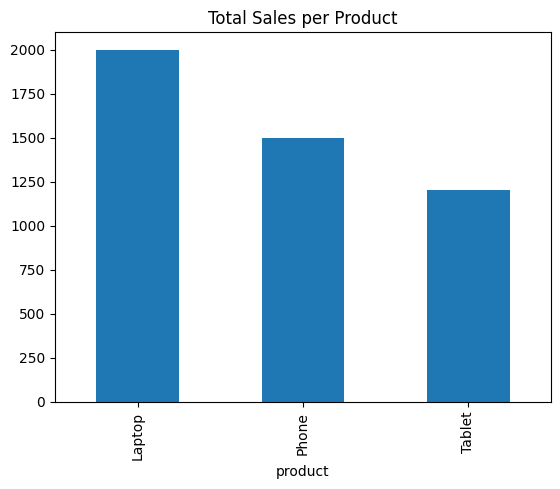

In [6]:
import matplotlib.pyplot as plt

result.plot(kind="bar")
plt.title("Total Sales per Product")
plt.show()